# BIND, end to end: from a dark-matter patch to baryonic-feedback inference

**BIND** turns a cheap dark-matter-only (DMO) simulation into the *baryonic* sky —
weak-lensing convergence $\kappa$, thermal-SZ Compton-$y$, and the electron column
$\tau$ (kSZ / dispersion measure) — calibrated to the CAMELS-IllustrisTNG hydro
suite, and then **emulates every field-level statistic of that sky in
milliseconds** as a function of the 30-dimensional galaxy-formation (feedback)
parameter vector.

This notebook walks the whole stack:

| stage | what happens | cost |
|---|---|---|
| 1. **BIND paint** | DMO density + $\theta$ $\to$ hydro fields (DM, gas, stars, $y$, $T$, …) per halo | seconds–min / box (GPU) |
| 2. **Ray-trace (lux)** | painted slabs $\to$ lensed $\kappa$ + line-of-sight $y,\tau$ maps | min / lightcone |
| 3. **Statistics** | maps $\to$ $C_\ell$, peaks, PDF, Minkowski, WST, DM, $Y$–$M$ … | min |
| 4. **GP emulator** | $\theta\,(+z_s)\to$ **all** of the above | **~ms** |
| 5. **Errors** | propagate BIND $\otimes$ GP $\otimes$ cosmic variance | — |
| 6. **Science** | what you can infer at fixed cosmology | — |

Stages 1–3 are the expensive forward model; stage 4 is the point of the whole
exercise — an instant, differentiable surrogate for it.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import bind

CEPH = Path("/mnt/home/mlee1/ceph")
FIDUCIAL = CEPH / "bind_lightcone_tng"                      # the high-N_real fiducial lightcone
WEIGHTS  = Path("/mnt/home/mlee1/BIND/weights/fm_redshift_thermo")
BUNDLE   = CEPH / "bind_sb35/emulator/lightcone_emulator_gp.pt"
DATASET  = CEPH / "bind_sb35/emulator_dataset.npz"
def have(p): return Path(p).exists()
print("assets:", {k: have(v) for k, v in
      dict(fiducial_maps=FIDUCIAL/"kappa_maps.npz", weights=WEIGHTS/"last.ckpt",
           emulator=BUNDLE, dataset=DATASET).items()})

assets: {'fiducial_maps': True, 'weights': True, 'emulator': True, 'dataset': True}


## 1. BIND paints baryons onto dark matter

BIND is a **conditional flow-matching generative model**. Given a DMO density
projection (the *condition*) and the 35-dim CAMELS parameter vector, it *samples* a
plausible set of hydrodynamic fields — `[DM_hydro, Gas, Stars]` as 128×128 maps,
plus four gas-thermodynamic channels (`compton_y, T, entropy, P_e`). It learned the
conditional distribution $P(\text{hydro}\mid\text{DMO}, \theta)$ from CAMELS hydro,
so it reproduces not just the mean baryon response but its **scatter** — that
stochasticity matters for the error budget in §5.

First, the input: a single DMO halo patch from the bundled demo.

demo patch: {'condition': (128, 128), 'large_scale': (3, 128, 128), 'params': (35,), 'target': (3, 128, 128)}


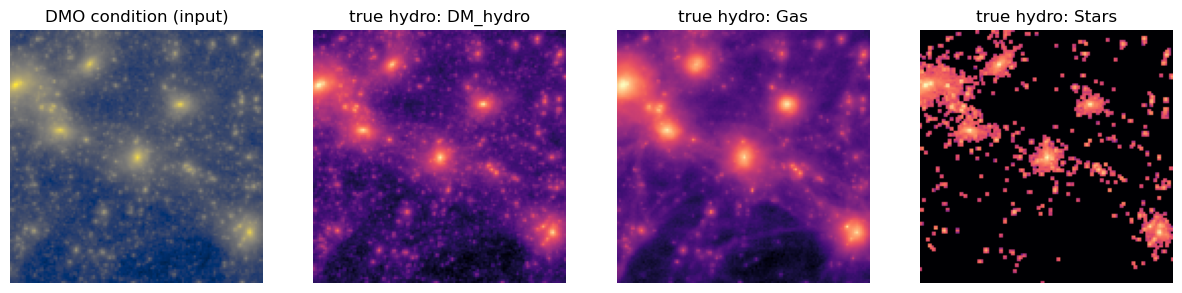

In [2]:
demo = np.load("data/dmo_sample.npz")
print("demo patch:", {k: demo[k].shape for k in demo.files})
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
ax[0].imshow(np.log10(demo["condition"] + 1), cmap="cividis"); ax[0].set_title("DMO condition (input)")
for i, name in enumerate(["DM_hydro", "Gas", "Stars"]):
    ax[i + 1].imshow(np.log10(demo["target"][i] + 1), cmap="magma")
    ax[i + 1].set_title(f"true hydro: {name}")
for a in ax: a.axis("off")
plt.show()

Now run BIND itself: load the trained model and **sample** the hydro fields for
this patch with the flow-matching ODE. The output is a *draw* from $P(\cdot\mid
\text{DMO},\theta)$ — re-running gives a different (statistically consistent) field.

generated [DM,Gas,Stars] (7, 128, 128) in 3.9s


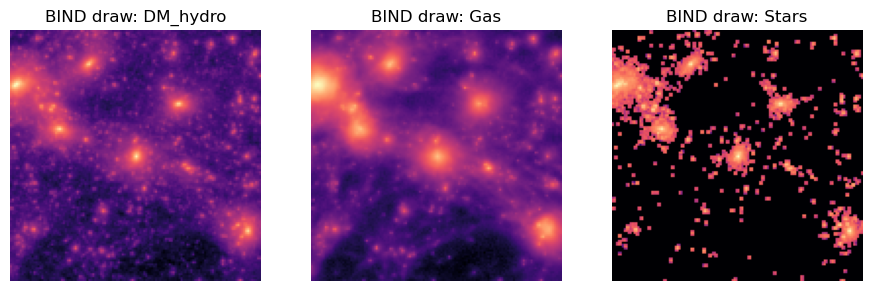

In [3]:
if have(WEIGHTS / "last.ckpt"):
    model = bind.Model.from_local(WEIGHTS)                 # flow-matching checkpoint + norm stats
    cutout = {"condition": demo["condition"], "large_scale": demo["large_scale"]}
    t = time.time()
    gen = model.generate([cutout], params=demo["params"], n_steps=50, progress=False)[0]
    print(f"generated [DM,Gas,Stars] {gen.shape} in {time.time()-t:.1f}s")
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    for i, name in enumerate(["DM_hydro", "Gas", "Stars"]):
        ax[i].imshow(np.log10(gen[i] + 1), cmap="magma"); ax[i].set_title(f"BIND draw: {name}")
        ax[i].axis("off")
    plt.show()
else:
    print("weights not found — run `bind-download-weights fm_two_head` first")

Over a whole box BIND paints every halo and composites the patches back onto
full-box maps. Here are real painted halos from one lightcone slab — the mass
channels *and* the thermodynamics that give us $y$ and $\tau$:

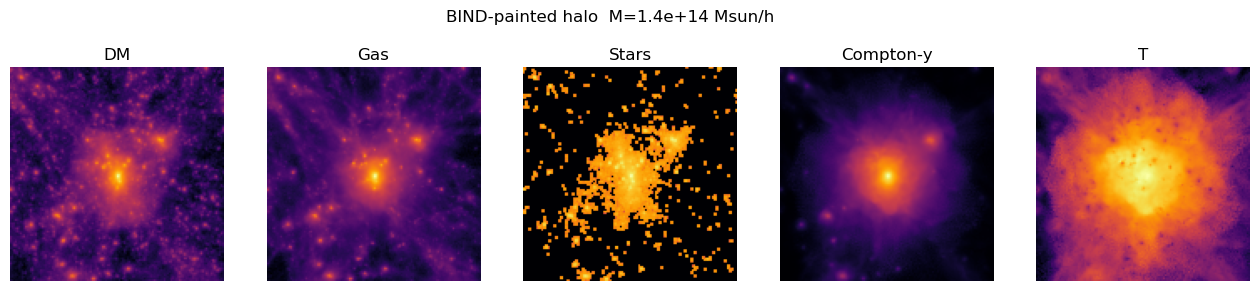

In [4]:
import glob
slabs = sorted(glob.glob(str(CEPH / "bind_sb35/runs/run_0000/snap_*/composite_slab00.npz")))
if slabs:
    d = np.load(slabs[len(slabs)//2])
    gen, thr = d["generated_patches"], d["thermo_patches"]      # (n,3,P,P), (n,4,P,P)
    h = int(np.argmax(d["halo_masses"]))                        # the most massive halo
    fig, ax = plt.subplots(1, 5, figsize=(16, 3.4))
    for i, (arr, name) in enumerate([(gen[h,0],"DM"),(gen[h,1],"Gas"),(gen[h,2],"Stars"),
                                     (thr[h,0],"Compton-y"),(thr[h,1],"T")]):
        ax[i].imshow(np.log10(np.abs(arr)+1e-8), cmap="inferno")
        ax[i].set_title(name); ax[i].axis("off")
    fig.suptitle(f"BIND-painted halo  M={d['halo_masses'][h]:.1e} Msun/h")
    plt.show()
else:
    print("no composite slabs found")

## 2. Ray-tracing the lightcone (lux)

The painted slabs are stacked along the line of sight into a lightcone. **lux**
ray-traces it: the convergence $\kappa$ is integrated along the *deflected* ray
(post-Born), while the additive secondaries — Compton-$y$ (pressure) and $\tau$
(electron column) — are accumulated at the bent-ray position. We output **5
tomographic source planes** ($z_s = 0.5,1,1.5,2,2.44$) on a common 5° grid, so
$\kappa$, $y$, $\tau$ are pixel-aligned and every cross-spectrum is immediate.

maps (50, 5, 1024, 1024)  fov=5.0 deg  z_s=[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.44)]


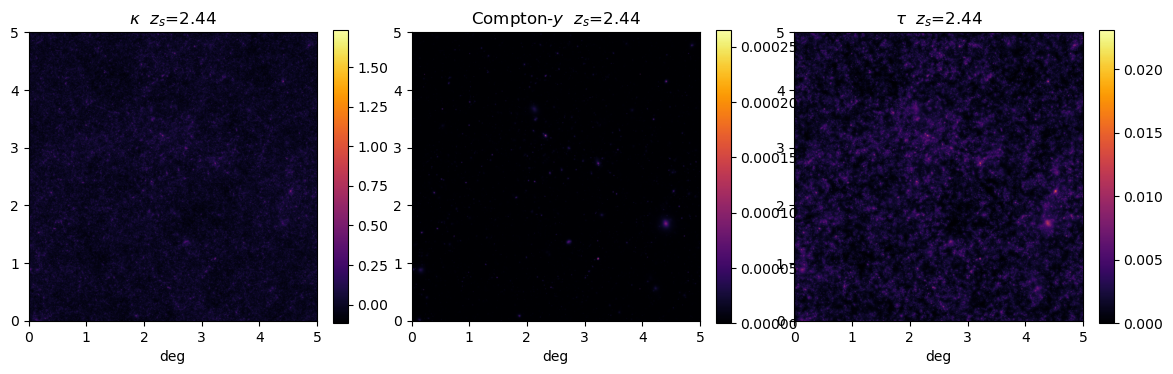

In [5]:
km = np.load(FIDUCIAL / "kappa_maps.npz")
ym = np.load(FIDUCIAL / "y_maps.npz"); tm = np.load(FIDUCIAL / "tau_maps.npz")
kappa, ymap, tau = km["kappa"], ym["y"], tm["tau"]            # (n_real, n_src, N, N)
zs = km["source_redshifts"]; fov = float(km["fov_deg"])
print(f"maps {kappa.shape}  fov={fov} deg  z_s={list(zs)}")
r, s = 0, -1                                                  # realization 0, deepest source plane
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))
for a, m, name in zip(ax, [kappa[r,s], ymap[r,s], tau[r,s]], [r"$\kappa$", "Compton-$y$", r"$\tau$"]):
    im = a.imshow(m, cmap="inferno", extent=[0, fov, 0, fov]); a.set_title(f"{name}  $z_s$={zs[s]:.2f}")
    a.set_xlabel("deg"); plt.colorbar(im, ax=a, fraction=0.046)
plt.show()

## 3. Mining statistics from the maps

From each map we extract a long data vector. Let's compute a few **live** off the
fiducial $\kappa$ map with the same estimators the pipeline uses
(`bind.inference.stats`): the lensing power spectrum, the peak counts, and the
one-point PDF.

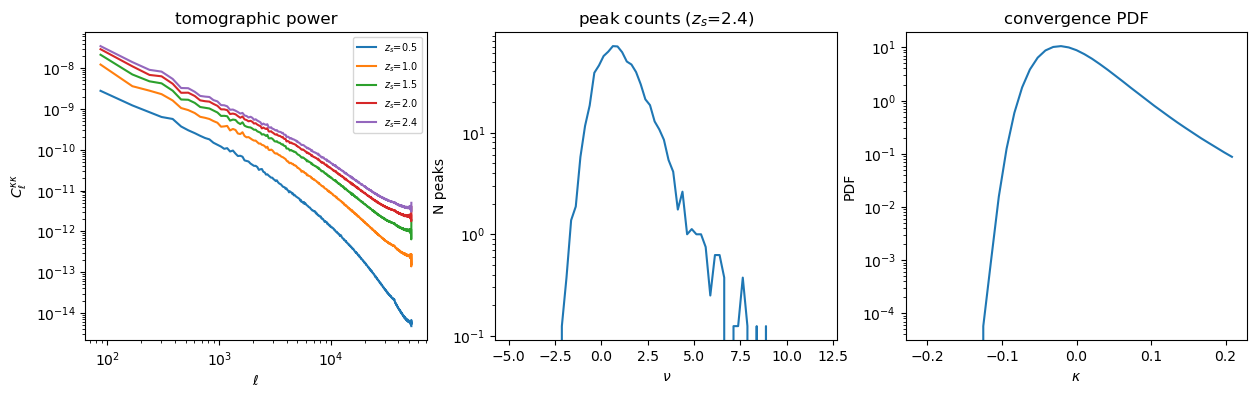

the full data vector also includes: minima, Minkowski V0/V1/V2, WST, DM PDF, R(nu)=<y>/<kappa> at peaks, Cl^{ky/yy/kt/tt/yt}, and the Y-M relation.


In [6]:
from bind.inference import stats as S
km5 = kappa[:8]                                              # 8 realizations for speed
ck = S.cl_kappa(km5, fov_deg=fov)
pk = S.peak_counts(km5, fov_deg=fov, smoothing_arcmin=2.0)
ng = S.nongaussian_stats(km5, fov_deg=fov)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i in range(5):
    ax[0].loglog(ck["ell"], ck["cl"][i, i], label=f"$z_s$={zs[i]:.1f}")
ax[0].set(xlabel=r"$\ell$", ylabel=r"$C_\ell^{\kappa\kappa}$", title="tomographic power"); ax[0].legend(fontsize=7)
ax[1].semilogy(pk["nu"], pk["peak_counts"][-1]); ax[1].set(xlabel=r"$\nu$", ylabel="N peaks", title="peak counts ($z_s$=2.4)")
ax[2].plot(ng["pdf_bins"], ng["pdf"][-1]); ax[2].set(xlabel=r"$\kappa$", ylabel="PDF", title="convergence PDF", yscale="log")
plt.show()
print("the full data vector also includes: minima, Minkowski V0/V1/V2, WST, DM PDF,"
      " R(nu)=<y>/<kappa> at peaks, Cl^{ky/yy/kt/tt/yt}, and the Y-M relation.")

**This is the expensive part.** Producing one such data vector for a *new*
feedback model means paint → ray-trace → reduce: GPU-hours per parameter point.
Doing inference needs thousands of points. That is exactly what the emulator removes.

## 4. The emulator: the whole pipeline in milliseconds

We ran stages 1–3 over a **Sobol design of the 30-d feedback space** (~237 points
at fixed TNG300 cosmology, 50 lightcone realizations each) and trained a surrogate
$\theta\,(+z_s) \to$ **every statistic**. Each statistic is compressed (transform →
PCA) and a **Gaussian process** regresses the PCA coefficients (GPU-accelerated,
`gpytorch`). The GP is the right tool here: with a few-hundred points in 30-d its
smooth prior interpolates the feedback response and gives analytic error bars,
where an MLP or normalizing flow over-fits (see the benchmark below).

In [7]:
from bind.emulator.core import Emulator
em = Emulator.load(BUNDLE)
print(em.describe())

Emulator (gpgpu): 23 statistics, z_s=[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.44)]
  cl_kappa         axis=ell [86.91, 5.213e+04] (n=724)
  cl_kappa_y       axis=ell [86.91, 5.213e+04] (n=724)
  cl_yy            axis=ell [86.91, 5.213e+04] (n=724)
  cl_kappa_tau     axis=ell [86.91, 5.213e+04] (n=724)
  cl_tt            axis=ell [86.91, 5.213e+04] (n=724)
  cl_yt            axis=ell [86.91, 5.213e+04] (n=724)
  peak_counts      axis=nu [-4.875, 11.88] (n=68)
  minima_counts    axis=nu [-4.875, 11.88] (n=68)
  pdf              axis=pdf_bins [-0.2214, 0.2214] (n=41)
  mf_v0            axis=mf_nu [-3, 4] (n=29)
  mf_v1            axis=mf_nu [-3, 4] (n=29)
  mf_v2            axis=mf_nu [-3, 4] (n=29)
  moments          axis=smoothing_scales_arcmin [1, 8] (n=4)
  wst              (no resamplable bin axis)
  dm_pdf           axis=dm_bins [60.73, 4918] (n=41)
  dm_moments       (no resamplable bin axis)
  peak_R           axis=nu [1.25, 11.75] (n=14)
 

predicted 23 statistics + derived in 722 ms


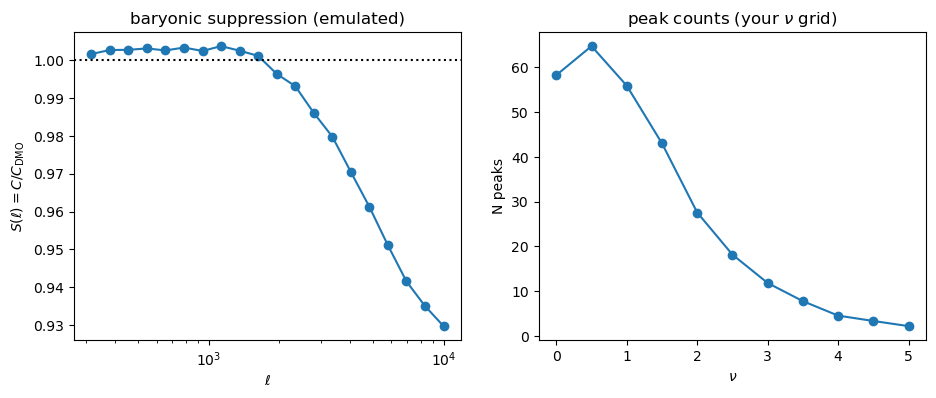

In [8]:
# predict EVERY statistic for a feedback vector, at a chosen source redshift
theta = bind.fiducial_params()
t = time.perf_counter(); out = em.predict(theta, z_s=1.0); dt = 1e3*(time.perf_counter()-t)
print(f"predicted {len(em.statistics)} statistics + derived in {dt:.0f} ms")

# the API also lets you select statistics and resample onto your own grids
my = em.predict(theta, z_s=1.0, stats=["suppression", "peak_counts"],
                grids={"ell": np.logspace(2.5, 4, 20), "nu": np.linspace(0, 5, 11)})
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(my["axes"]["ell"], my["suppression"], "o-")
ax[0].axhline(1, ls=":", c="k"); ax[0].set(xlabel=r"$\ell$", ylabel=r"$S(\ell)=C/C_{\rm DMO}$",
    title="baryonic suppression (emulated)")
ax[1].plot(my["axes"]["nu"], my["peak_counts"], "o-"); ax[1].set(xlabel=r"$\nu$", ylabel="N peaks",
    title="peak counts (your $\\nu$ grid)")
plt.show()

**Backend choice (measured on held-out interior points).** The GP wins on
accuracy *and* speed; the flow is a generative density model that needs far more
data to match it on point prediction (its real use is sampling mock data vectors);
the MLP collapses toward the prior mean in this small-data / high-dim regime.

| backend | fit time | $S(\ell)$ median frac. err | dip correlation |
|---|---|---|---|
| **GP (gpgpu)** | 4 s | **2.0 %** | **0.87** |
| normalizing flow | 60 s | 2.4 % | 0.86 |
| MLP ensemble | 8 s | 4.9 % | 0.77 |

## 5. Where does the error come from? (an emulator of an emulator)

There are **two emulators stacked**, plus the finiteness of the sky:

1. **BIND** (DMO → hydro) is *generative*: it has an intrinsic **scatter**
   (it samples a field, not a point) and a possible **bias** vs true hydro.
2. **The GP** ($\theta$ → statistic) is an *interpolator*: it has **epistemic
   uncertainty** that shrinks as the Sobol design grows.
3. **Cosmic variance**: a 5° patch is one finite realization of the universe.

How we capture each:

* **Cosmic variance + BIND stochasticity** are measured *together* by the **50
  lightcone realizations** at each design point — re-painting + re-ray-tracing with
  different phases. Their scatter is the field-level (data) covariance, and it
  already folds in BIND's generative noise.
* **GP epistemic uncertainty** is the GP's analytic predictive $1\sigma$
  (`predict(..., return_std=True)` → `*_err`).
* **BIND bias vs hydro** is a *systematic*, characterized by the closure tests
  against TNG300 full hydro (BIND $\approx$ TNG300 at fiducial for $C_\ell$, peaks,
  $C_\ell^{yy}$, $R(\nu)$); it is corrected/marginalized, not random.

Let's see which term dominates for the suppression $S(\ell)$.

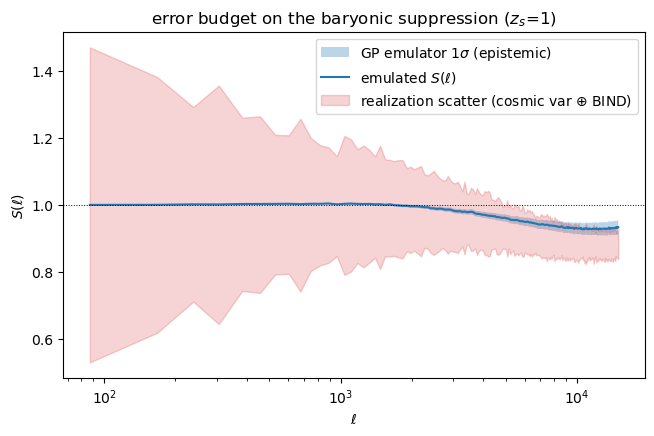

For inference the total predictive covariance = realization covariance (cosmic var + BIND scatter) + GP emulator variance; the BIND-vs-hydro bias is a separate systematic from the closure tests.


In [9]:
# GP emulator 1-sigma (epistemic) vs the 50-realization scatter (cosmic var + BIND)
ell = em.bin_values["suppression"]
o = em.predict(theta, z_s=1.0)
gp_sigma = o.get("suppression_err")                         # GP analytic 1-sigma
# realization scatter of S from the fiducial run's stored C_ell error (std/sqrt(50))
ckf = np.load(FIDUCIAL / "Cl_kappa.npz")
i_zs = int(np.argmin(np.abs(zs - 1.0)))
auto = ckf["cl"][i_zs, i_zs]; auto_real_std = ckf["cl_err"][i_zs, i_zs] * np.sqrt(50)
S_fid = auto / em.cl_dmo[i_zs]
real_sigma = auto_real_std / em.cl_dmo[i_zs]               # per-realization scatter on S
trust = ell < 1.5e4
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(ell[trust], (o["suppression"]-gp_sigma)[trust] if gp_sigma is not None else o["suppression"][trust],
                (o["suppression"]+gp_sigma)[trust] if gp_sigma is not None else o["suppression"][trust],
                alpha=.3, label="GP emulator $1\\sigma$ (epistemic)")
ax.plot(ell[trust], o["suppression"][trust], "C0", label="emulated $S(\\ell)$")
ax.fill_between(ell[trust], (S_fid-real_sigma)[trust], (S_fid+real_sigma)[trust],
                color="C3", alpha=.2, label="realization scatter (cosmic var $\\oplus$ BIND)")
ax.axhline(1, ls=":", c="k", lw=.7); ax.set(xscale="log", xlabel=r"$\ell$", ylabel=r"$S(\ell)$")
ax.legend(); ax.set_title("error budget on the baryonic suppression ($z_s$=1)"); plt.show()
print("For inference the total predictive covariance = realization covariance "
      "(cosmic var + BIND scatter) + GP emulator variance; the BIND-vs-hydro bias "
      "is a separate systematic from the closure tests.")

**Takeaway.** At the scales that carry the baryon signal the *cosmic-variance
+ BIND* scatter (a 5° patch) dominates the *GP* uncertainty — i.e. the emulator is
already below the noise floor of the data it predicts, and more Sobol points shrink
the (subdominant) GP term further. A real analysis adds the GP variance to the
realization covariance and treats the BIND→hydro bias with the closure-test
calibration.

## 6. Fixed cosmology — so what is this *for*?

The Sobol suite varies only the **30 feedback parameters**; cosmology is pinned at
TNG300. So this tool does **not** directly constrain $\Omega_m, \sigma_8$. That is a
feature to own, not a bug — and it is still squarely useful:

**1. Inferring galaxy-formation physics from the sky.** Point the emulator at real
WL + tSZ + kSZ field-level data and run SBI/Fisher over the 30-d feedback space (or
the derived $f_{\rm gas}$, $Y$–$M$, $S(\ell)$). This is the first forward model that
predicts **non-Gaussian + cross statistics** ($\kappa$ peaks, $\kappa\times y$,
$\tau$) from a full hydro-calibrated model — exactly the new observables needed to
**adjudicate the "is feedback stronger than the simulations?" debate** (kSZ + X-ray
$f_{\rm gas}$ vs TNG/FLAMINGO).

**2. A hydro-calibrated baryon model for *cosmology*.** Even at fixed cosmology the
emulator delivers $S(\ell)$ — the baryonic suppression — with calibrated scatter.
That is the nuisance template Stage-IV lensing needs to **marginalize baryons and
unlock small scales**: ~2 baryon templates remove the TNG baryonic $S_8$ bias, at a
fraction of the cost of a 7-param BCM. Suppression *ratios* are only weakly
cosmology-dependent, so a fixed-cosmology training set transfers.

**3. Multi-probe consistency from one model.** $\kappa$, $y$, $\tau$ are predicted
*jointly and pixel-aligned*, so you get $\kappa\times y$, $\kappa\times\tau$,
$y\times\tau$ and a **thermodynamic decomposition of lensing peaks** into (total
mass, $f_{\rm gas}$, $\bar T$) — a stronger, falsifiable statement than any single
probe.

**4. Speed makes the science possible.** What was GPU-hours per model is now
milliseconds, so full posterior inference over a 30-d feedback space — previously
intractable — becomes routine.

**The honest scope.** *Paper II*: feedback constraints + information-recovery at
fixed cosmology. *Paper III*: paint BIND on a cosmology grid of DMO lightcones
(CosmoGrid-class) for joint (cosmology, astrophysics) inference. The machinery in
this notebook is exactly what both papers run on.

In [10]:
print("You have now seen the whole stack:")
print("  DMO patch --BIND--> hydro fields --lux--> kappa/y/tau maps --stats--> data vector")
print("  ... all replaced by:  Emulator.load(...).predict(theta, z_s)  in ~ms.")
print("Next: examples/lightcone_emulator.ipynb (train/validate) and"
      " examples/emulator_showcase.py (emulator vs ray-traced truth).")

You have now seen the whole stack:
  DMO patch --BIND--> hydro fields --lux--> kappa/y/tau maps --stats--> data vector
  ... all replaced by:  Emulator.load(...).predict(theta, z_s)  in ~ms.
Next: examples/lightcone_emulator.ipynb (train/validate) and examples/emulator_showcase.py (emulator vs ray-traced truth).
